<a href="https://colab.research.google.com/github/AKookani/Qiskit_course/blob/Main/Qiskit0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Quantum Coding Course** (summer 2024)

**Instructors:**
Ali Kookani, Yousef Mafi

\

*Atlas Stem*

# Section 1: Quantum Circuits and Qiskit introduction

*   Install Qiskit library
*   Defining quantum circuits
*   Apply quantum gates
*   Controlled gates
*   Measurement
*   Quantum Circuit details
*   Parametric gates
*   Quantum circuit manipulation
*   QASM
*   Arbitrary gates
*   Variational quantum gates


## Install Qiskit library

We can install any library in colab with comment, "*!pip install [library name]*"

In [1]:
# Install the Qiskit library for quantum computing and ipywidgets for interactive widgets in Jupyter notebooks
!pip install qiskit ipywidgets

#why not !pip install qiskit?

# Install the pylatexenc library for rendering LaTeX in Matplotlib figures
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=a9694f65e958caae2cfcbedd1976374b9b172ac9239d2a42c08bfd0e6a20b456
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


**Improt libraries**

In [2]:
import qiskit
print(qiskit.__version__)

2.3.1


In [3]:
import math
from qiskit import QuantumCircuit

qc = QuantumCircuit(4)  # Define a 4-qubit quantum circuit

## Defining quantum circuits

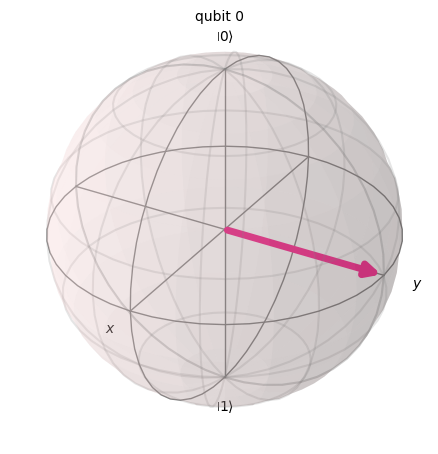

In [4]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
qc = QuantumCircuit(1)
qc.h(0)
qc.s(0)
state = Statevector.from_instruction(qc)
state.draw('bloch')

## Apply quantum gates


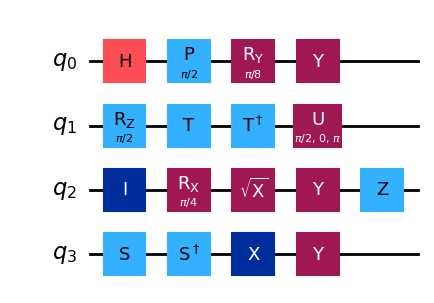

In [5]:
qc = QuantumCircuit(4)
qc.h(0)   # Hadamard gate
qc.id(2)    # Identity gate
qc.p(math.pi/2,0)   # Phase gate
qc.rx(math.pi/4,2)    # Rotation (around x-axis) gate
qc.ry(math.pi/8,0)    # Rotation (around y-axis) gate
qc.rz(math.pi/2,1)    # Rotation (around z-axis) gate
qc.s(3)   # S gate
qc.sdg(3)   # Conjugate transpose of S gate
qc.sx(2)    # Sx gate
qc.t(1)   # T gate
qc.tdg(1)   # Conjugate transpose of T gate
qc.u(math.pi/2,0,math.pi,1)   # Universal gate
qc.x(3)   # X gate (Quantum NOT gate)
qc.y([0,2,3])   # Y gate
qc.z(2)   # Z gate

display(qc.draw('mpl'))   # Display quantum circuit

## Controlled quantum gates

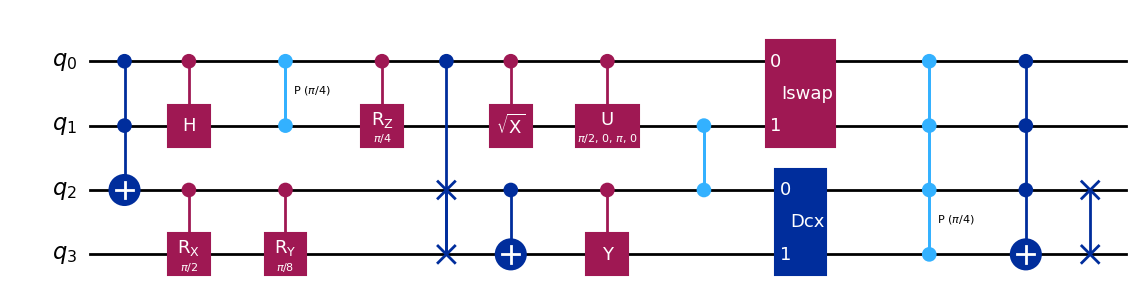

In [6]:
# Define 4-qubit quantum circuit
qc = QuantumCircuit(4)

qc.ccx(0,1,2)   # Toffoli gate
qc.ch(0,1)    # Controlled Hadamard gate
qc.cp(math.pi/4,0,1)    # Controlled Phase gate
qc.crx(math.pi/2,2,3)   # Controlled Rotation (around x-axis) gate
qc.cry(math.pi/8,2,3)   # Controlled Rotation (around y-axis) gate
qc.crz(math.pi/4,0,1)   # Controlled Rotation (around z-axis) gate
qc.cswap(0,2,3)   # Controlled Swapping gate
qc.csx(0,1)   # Controlled Sx gate
qc.cu(math.pi/2,0,math.pi,0,0,1)    # Controlled Universal gate
qc.cx(2,3)    # Controlled X (CNOT) gate
qc.cy(2,3)    # Controlled Y gate
qc.cz(1,2)    # Controlled Z gate
# Apply a DCX (Double-CNOT) gate with qubit 2 and qubit 3
qc.dcx(2,3)
# Apply an iSWAP gate between qubit 0 and qubit 1
qc.iswap(0,1)
# Apply Multi-controlled quantum gates
qc.mcp(math.pi/4, [0,1,2],3)
qc.mcx([0,1,2],3)
qc.swap(2,3)    # Swap gate

display(qc.draw('mpl'))   # Display quantum circuit

**Greenberger–Horne–Zeilinger state (GHZ state):**

$|GHZ\rangle=\frac{|000\rangle+|111\rangle}{\sqrt{2}}$

In [7]:
# Define 3-qubit quantu circuit
qc = QuantumCircuit(3)
# GHZ state
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

qc.draw()   # draw quantum circuit

┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

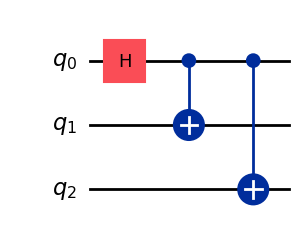

In [8]:
qc.draw('mpl') # mpl needs "pylatexenc" to be installed beforehand not to run into any errors

Distinguish quantum system with a **Barrier**

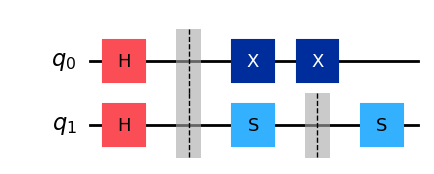

In [9]:
# Define 2-qubit quantum system
qc = QuantumCircuit(2)

qc.h([0,1])   # Apply two H-gates on first and second qubit
qc.barrier() #Puts a barrier on the whole circuit
qc.x(0)
qc.x(0)
qc.s(1)
qc.barrier([1]) #Puts a barrier on qubit 1 (second)
qc.s(1)

qc.draw("mpl")   # Display quantum circuit

## Measurement

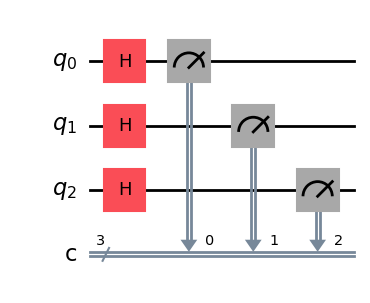

In [10]:
# Creates 3 qubit quantum circuit and 3 bit circuit
qc = QuantumCircuit(3, 3)

qc.h([0,1,2]) # Applies Hadamard gate on the numbers of a given list
qc.measure([0,1,2], [0,1,2]) # Measures qubits of the first list and returns them on bits of the second list

qc.draw("mpl")   # Display quantum circuit

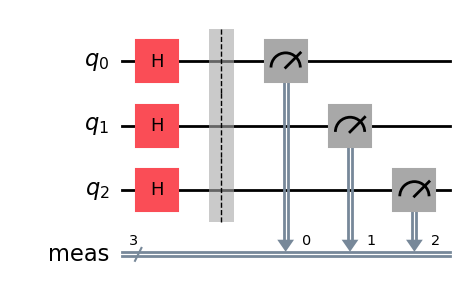

In [11]:
# Creates 3 qubit quantum circuit
qc = QuantumCircuit(3)

qc.h([0,1,2])
qc.measure_all() # Measures all qubits automatically

qc.draw("mpl")   # Display quantum circuit

## Quantum Circuit details

In [12]:
# Print the depth of the quantum circuit `qc`.
# The depth is the length of the longest path from the beginning to the end of the circuit, in terms of gate layers.
# It indicates the circuit's complexity in terms of the number of sequential operations.
print(f"depth of the circuit is: {qc.depth()}")

# Print the total number of gates (operations) in the quantum circuit `qc`.
# This includes all operations like gates and measurements that have been applied in the circuit.
print(f"total number of circuit's gates is: {qc.size()}")

# Print the total number of wires (both quantum and classical) in the quantum circuit `qc`.
# This corresponds to the combined number of qubits and classical bits used in the circuit.
print(f"total number of circuit's wires is: {qc.width()}")

depth of the circuit is: 2
total number of circuit's gates is: 6
total number of circuit's wires is: 6


In [13]:
# Print the list of classical bits in the quantum circuit `qc`.
# This will return a list of ClassicalRegister bits that the circuit uses for measurements.
print(qc.clbits)

# Print the list of operations (gates) and their corresponding qubits in the quantum circuit `qc`.
# This will output all instructions in the circuit including gates, measurements, etc.
print(qc.data)

# Print the global phase of the quantum circuit `qc`.
# The global phase is a property of the circuit that affects the overall phase of the quantum state, but not the measurement results.
print(f"circuit's global phase is: {qc.global_phase}")

# Print the total number of classical bits (classical wires) in the quantum circuit `qc`.
# This value corresponds to the number of classical registers used for measurement or other classical control.
print(f"total number of circuit's classical wires is: {qc.num_clbits}")

# Print the total number of qubits (quantum wires) in the quantum circuit `qc`.
# This value represents the total number of qubits in the circuit.
print(f"total number of circuit's quantum wires is: {qc.num_qubits}")

# Print the list of quantum bits (qubits) in the quantum circuit `qc`.
# This will return a list of Qubit objects that represent the quantum registers in the circuit.
print(qc.qubits)

[<Clbit register=(3, "meas"), index=0>, <Clbit register=(3, "meas"), index=1>, <Clbit register=(3, "meas"), index=2>]
[CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=1>,), clbits=()), CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=2>,), clbits=()), CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=()), CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(<Qubit register=(3, "q"), index=0>,), clbits=(<Clbit register=(3, "meas"), index=0>,)), CircuitInstruct

**Some other gates**

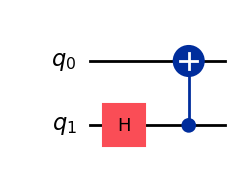

In [14]:
# Import the CXGate class from the qiskit.circuit.library module
from qiskit.circuit.library import CXGate

# Create a quantum circuit with 2 qubits
qc = QuantumCircuit(2)

# Apply a Hadamard gate to the second qubit (index 1)
qc.h(1)

# Instantiate a CNOT (Controlled-NOT) gate
cx_gate = CXGate()

# Append the CNOT gate to the quantum circuit, targeting qubit 1 as control and qubit 0 as target
qc.append(cx_gate, [1, 0])

# Draw the quantum circuit using Matplotlib for visualization
qc.draw("mpl")

## Parametric gates

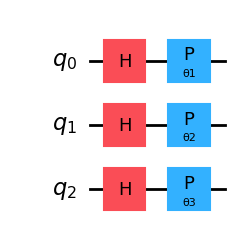

In [15]:
# Import the QuantumCircuit class and the Parameter class from the qiskit.circuit module
from qiskit.circuit import QuantumCircuit, Parameter

# Create three parameter objects to represent variable rotation angles
theta1 = Parameter('θ1')
theta2 = Parameter('θ2')
theta3 = Parameter('θ3')

# Create a quantum circuit with 3 qubits
qc = QuantumCircuit(3)

# Apply Hadamard gates to all three qubits (qubits 0, 1, and 2)
qc.h([0, 1, 2])

# Apply a parameterized phase gate to qubit 0 with angle θ1
qc.p(theta1, 0)

# Apply a parameterized phase gate to qubit 1 with angle θ2
qc.p(theta2, 1)

# Apply a parameterized phase gate to qubit 2 with angle θ3
qc.p(theta3, 2)

# Draw the quantum circuit using Matplotlib for visualization
qc.draw("mpl")

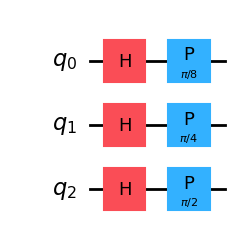

In [16]:
# Bind the parameters to specific values using assign_parameters
# θ1 is set to π/8
# θ2 is set to π/4
# θ3 is set to π/2
b_qc = qc.assign_parameters({theta1: math.pi/8,
                             theta2: math.pi/4,
                             theta3: math.pi/2})

b_qc.draw("mpl")

## Quantum circuit manipulation

**Combination of two different quantum circuits**

First quantum circuit


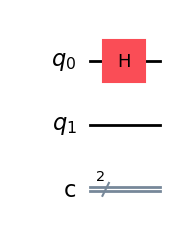

Second quantum circuit


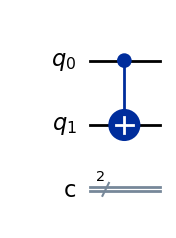

Composed quantum circuit


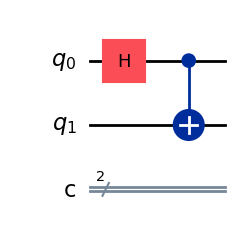

In [17]:
# Create a quantum circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Apply a Hadamard gate to the first qubit (index 0) to create a superposition
qc.h(0)

print("First quantum circuit")
display(qc.draw("mpl"))
# Create another quantum circuit with 2 qubits and 2 classical bits
another_qc = QuantumCircuit(2, 2)

# Apply a CNOT (Controlled-NOT) gate with the first qubit (index 0) as control
# and the second qubit (index 1) as target to entangle them
another_qc.cx(0, 1)

print("Second quantum circuit")
display(another_qc.draw("mpl"))
# Combine the two quantum circuits by composing them
# The gates from another_qc will be applied after the gates in qc
bell_qc = qc.compose(another_qc)

# Draw the resulting combined quantum circuit using Matplotlib for visualization
print("Composed quantum circuit")
display(bell_qc.draw("mpl"))

**Copy of orginal quantum circuit**

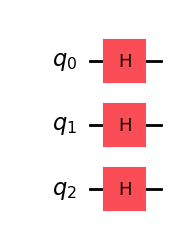

In [18]:
# Create a quantum circuit with 3 qubits
qc = QuantumCircuit(3)

# Apply Hadamard gates to all three qubits (qubits 0, 1, and 2)
# This creates a superposition state for each qubit
qc.h([0, 1, 2])

# Create a copy of the original quantum circuit
new_qc = qc.copy()

# Draw the copied quantum circuit using Matplotlib for visualization
new_qc.draw("mpl")

**Decompose quantum circuit to fundamental components**

the original quantum circuit


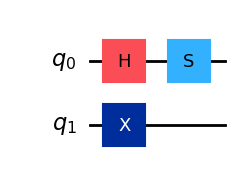

the decomposed quantum circuit


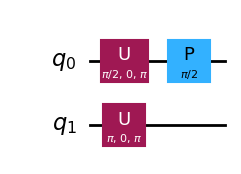

In [19]:
# Create a quantum circuit with 2 qubits
qc = QuantumCircuit(2)

# Apply a Hadamard gate to the first qubit (index 0)
qc.h(0)

# Apply an S gate (phase gate) to the first qubit (index 0)
qc.s(0)

# Apply an X gate (NOT gate) to the second qubit (index 1)
qc.x(1)

print("the original quantum circuit")
display(qc.draw("mpl"))

# Decompose the quantum circuit once
# This will break down the composite gates into their fundamental gate components
decomposed_qc = qc.decompose()

# Draw the decomposed quantum circuit using Matplotlib for visualization
print("the decomposed quantum circuit")
display(decomposed_qc.draw("mpl"))

the original quantum circuit


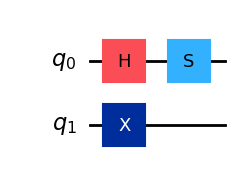

the decomposed quantum circuit


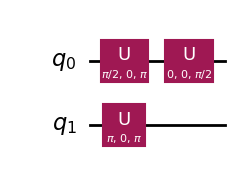

In [20]:
# Create a quantum circuit with 2 qubits
qc = QuantumCircuit(2)

# Apply a Hadamard gate to the first qubit (index 0)
qc.h(0)

# Apply an S gate (phase gate) to the first qubit (index 0)
qc.s(0)

# Apply an X gate (NOT gate) to the second qubit (index 1)
qc.x(1)

print("the original quantum circuit")
display(qc.draw("mpl"))
# Decompose the quantum circuit twice
# The first decomposition breaks down the composite gates into fundamental gate components
# The second decomposition ensures that the circuit is fully decomposed into the most basic gates
# Further decomposing will not change the circuit as it is already fully decomposed
decomposed_qc = qc.decompose().decompose()

# Draw the fully decomposed quantum circuit using Matplotlib for visualization
print("the decomposed quantum circuit")
display(decomposed_qc.draw("mpl"))

**Qubits initialization**

$|\psi\rangle=[0, 0, 0, 1]^T = |11\rangle$

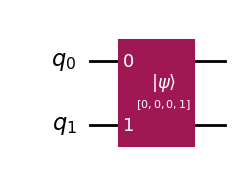

In [21]:
# Create a quantum circuit with 2 qubits
qc = QuantumCircuit(2)

# Initialize the quantum circuit with the state |11>
# The state vector [0, 0, 0, 1] represents the state |11> in the computational basis
qc.initialize([0, 0, 0, 1])

# Draw the quantum circuit using Matplotlib for visualization
qc.draw("mpl")

**Reset gate**

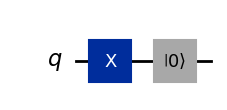

In [29]:
qc = QuantumCircuit(1)
qc.x(0)
qc.reset(0)
qc.draw("mpl")

## QASM

**QASM string coding**

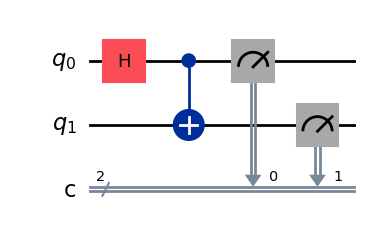

In [30]:
# Define a QASM string that describes a quantum circuit
qasm_str = """
OPENQASM 2.0;            // Specify the version of OpenQASM being used
include "qelib1.inc";    // Include the standard quantum gate library
qreg q[2];               // Declare a quantum register with 2 qubits
creg c[2];               // Declare a classical register with 2 bits
h q[0];                  // Apply a Hadamard gate to the first qubit (index 0)
cx q[0],q[1];            // Apply a CNOT gate with the first qubit as control and the second as target
measure q[0] -> c[0];    // Measure the first qubit and store the result in the first classical bit
measure q[1] -> c[1];    // Measure the second qubit and store the result in the second classical bit
"""

# Create a quantum circuit from the QASM string
new_qc = QuantumCircuit.from_qasm_str(qasm_str)

# Draw the quantum circuit using Matplotlib for visualization
new_qc.draw("mpl")

**Qiskit to QASM string**

In [31]:
# Create a quantum circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Apply a Hadamard gate to the first qubit (qubit 0)
qc.h(0)

# Apply a CNOT gate with the first qubit (qubit 0) as the control and the second qubit (qubit 1) as the target
qc.cx(0, 1)

# Convert the quantum circuit to a QASM (Quantum Assembly Language) string representation
qasm_str = qiskit.qasm3.dumps(qc)

# Print the QASM string
print(qasm_str)

OPENQASM 3.0;
include "stdgates.inc";
bit[2] c;
qubit[2] q;
h q[0];
cx q[0], q[1];



## Arbitrary gates

**Build a new gate**

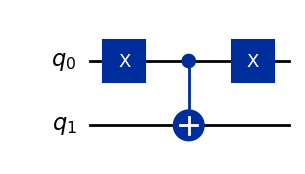

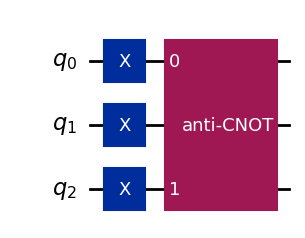

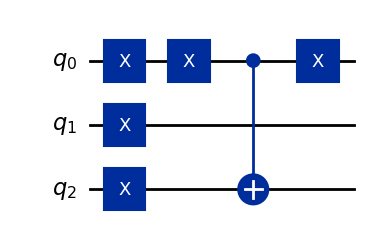

In [35]:
# Create a quantum circuit with 2 qubits
anti_cnot_qc = QuantumCircuit(2)

# Apply X (NOT) gate to the first qubit
anti_cnot_qc.x(0)

# Apply CNOT gate with control qubit 0 and target qubit 1
anti_cnot_qc.cx(0, 1)

# Apply X (NOT) gate again to the first qubit
anti_cnot_qc.x(0)

# Display the drawn circuit of the anti-CNOT
display(anti_cnot_qc.draw("mpl"))

# Convert the above circuit into a gate
anti_cnot_gate = anti_cnot_qc.to_gate(label='anti-CNOT')

# Display the gate definition
anti_cnot_gate.definition.draw("mpl")

# Create a new quantum circuit with 3 qubits
qc = QuantumCircuit(3)

# Apply X (NOT) gates to the first, second, and third qubits
qc.x([0, 1, 2])

# Append the anti-CNOT gate, using qubit 0 as control and qubit 2 as target
qc.append(anti_cnot_gate, [0, 2])

# Display the drawn circuit with the anti-CNOT gate appended
display(qc.draw("mpl"))

# Decompose ONLY the anti-CNOT gate by referencing its label
qc.decompose(gates_to_decompose="anti-CNOT").draw("mpl")

**Build an instruction from the quantum circuit**

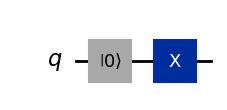

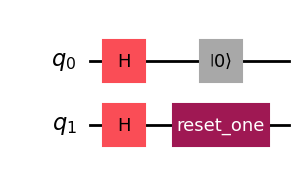

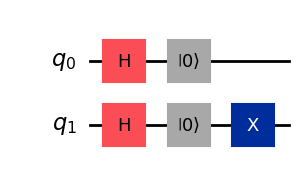

In [37]:
# Create a quantum circuit with 1 qubit
reset_one_qc = QuantumCircuit(1)

# Reset the qubit (set it to |0> state)
reset_one_qc.reset(0)

# Apply X (NOT) gate to the qubit (flip it to |1> state)
reset_one_qc.x(0)

# Display the drawn circuit
display(reset_one_qc.draw("mpl"))

# Convert the above circuit into an instruction
reset_one_inst = reset_one_qc.to_instruction(label="reset_one")

# Create a new quantum circuit with 2 qubits
qc = QuantumCircuit(2)

# Apply Hadamard gates to both qubits (put them into superposition)
qc.h([0, 1])

# Reset the first qubit (set it to |0> state)
qc.reset(0)

# Append the reset and X gate instruction to the second qubit
qc.append(reset_one_inst, [1])

# Display the drawn circuit with the reset and X gate instruction appended
display(qc.draw("mpl"))

# Decompose ONLY the reset_one instruction, leaving everything else intact
qc.decompose(gates_to_decompose="reset_one").draw("mpl")

**Define Registers**

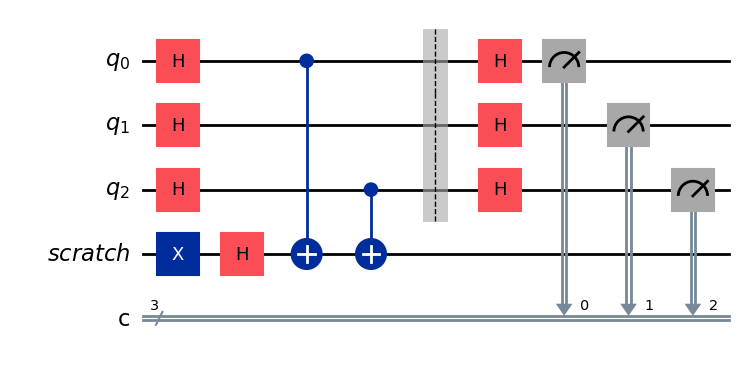

In [38]:
# Import necessary classes from Qiskit
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

# Create a quantum register with 3 qubits and label it 'q'
qr = QuantumRegister(3, 'q')

# Create an additional quantum register with 1 qubit for intermediate operations and label it 'scratch'
scratch = QuantumRegister(1, 'scratch')

# Create a classical register with 3 bits for measurement results and label it 'c'
cr = ClassicalRegister(3, 'c')

# Create a quantum circuit using the quantum registers and the classical register
qc = QuantumCircuit(qr, scratch, cr)

# Apply a Hadamard gate to each qubit in the main quantum register 'qr'
qc.h(qr)

# Apply an X (Pauli-X) gate to the qubit in the 'scratch' register
qc.x(scratch)

# Apply a Hadamard gate to the qubit in the 'scratch' register
qc.h(scratch)

# Apply a controlled-X (CNOT) gate with the first qubit of 'qr' as control and the 'scratch' qubit as target
qc.cx(qr[0], scratch)

# Apply a controlled-X (CNOT) gate with the third qubit of 'qr' as control and the 'scratch' qubit as target
qc.cx(qr[2], scratch)

# Add a barrier to prevent optimization across this point, preserving the sequence of operations
qc.barrier(qr)

# Apply a Hadamard gate again to each qubit in the main quantum register 'qr'
qc.h(qr)

# Measure the qubits in the main quantum register 'qr' and store the results in the classical register 'cr'
qc.measure(qr, cr)

# Draw the circuit diagram in matplotlib format
qc.draw("mpl")

**Multi-controlled gates**

In [39]:
from qiskit.circuit.library import CCXGate  # Import the CCXGate (Toffoli gate) from Qiskit's circuit library

# Create an instance of the Toffoli gate (also known as CCXGate)
toffoli = CCXGate()

# Print the number of control qubits for the Toffoli gate
# The Toffoli gate has 2 control qubits by definition
print(toffoli.num_ctrl_qubits)

2


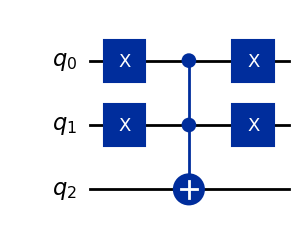

In [49]:
# Create the Toffoli gate (CCX gate)
toffoli = CCXGate()

# Convert to mutable
toffoli_mutable = toffoli.to_mutable()

# Modify the control state to be triggered by 2 (binary 10)
toffoli_mutable.ctrl_state = 0

# Draw the gate definition
toffoli_mutable.definition.draw("mpl")

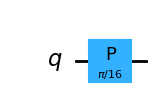

In [54]:
import math  # Import the math module to use mathematical functions and constants

# Create a quantum circuit with a single qubit
p16_qc = QuantumCircuit(1)

# Add a parameterized gate to the circuit (a phase gate with an angle of π/16)
# The 'p' method applies a phase shift to the qubit
p16_qc.p(math.pi / 16, 0)

# Convert the quantum circuit into a gate that can be reused in other circuits
p16_gate = p16_qc.to_gate()

# Draw the definition of the newly created gate
p16_gate.definition.draw("mpl")

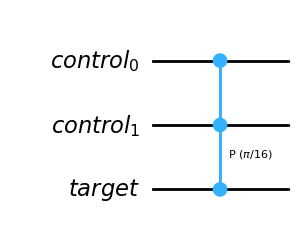

In [55]:
# Create a controlled version of the p16_gate with 2 control qubits
ctrl_p16 = p16_gate.control(num_ctrl_qubits=2, label="control p/16")

# Draw the definition (circuit) of the controlled p16_gate
ctrl_p16.definition.draw("mpl")

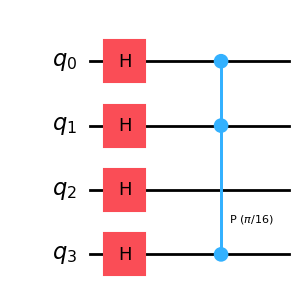

In [56]:
# Create a quantum circuit with 4 qubits
qc = QuantumCircuit(4)

# Apply Hadamard gates to qubits 0, 1, 2, and 3 to put them into superposition
qc.h([0, 1, 2, 3])

# Append the previously defined controlled p16_gate to the circuit
# Apply it with control qubits 0 and 1, and target qubit 3
qc.append(ctrl_p16, [0, 1, 3])

# Decompose the appended controlled p16_gate back into its basic gates and draw the circuit
qc.decompose(gates_to_decompose="control p/16").draw("mpl")

## Variational quantum gates

In [57]:
from qiskit.circuit import QuantumCircuit,ParameterVector
theta = ParameterVector('θ', 3)
print(theta)

θ, ['θ[0]', 'θ[1]', 'θ[2]']


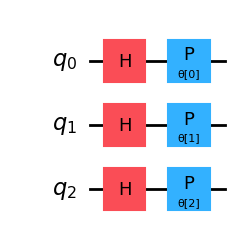

In [58]:
# Create a quantum circuit with 3 qubits
qc = QuantumCircuit(3)

# Apply Hadamard gates to qubits 0, 1, and 2 to put them into superposition
qc.h([0, 1, 2])

# Apply a parameterized phase gate to qubit 0 with the first parameter θ[0]
qc.p(theta[0], 0)

# Apply a parameterized phase gate to qubit 1 with the second parameter θ[1]
qc.p(theta[1], 1)

# Apply a parameterized phase gate to qubit 2 with the third parameter θ[2]
qc.p(theta[2], 2)

# Draw the circuit
qc.draw("mpl")

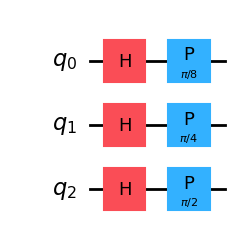

In [59]:
import math  # Import the math module for mathematical operations

# Assigning values to the quantum circuit parameters
# 'qc' is a predefined quantum circuit and 'theta' is a parameter in that circuit
# Here, we are assigning three specific values (pi/8, pi/4, pi/2) to the 'theta' parameter
b_qc = qc.assign_parameters({theta: [
    math.pi / 8,  # Assign pi/8 to the first instance of 'theta'
    math.pi / 4,  # Assign pi/4 to the second instance of 'theta'
    math.pi / 2   # Assign pi/2 to the third instance of 'theta'
]})

# Drawing the quantum circuit with the new parameter values using Matplotlib
b_qc.draw("mpl")